In [1]:
# Mulligan rules:
# 1.- Initial Draw 7 cards. If number of card types criteria is not met, return them to the deck and shuffle.
# 2.- First free Draw 7 cards. If number of card types criteria is not met, return them to the deck and shuffle.
# 3.- Take one last mulligan and Draw 7 cards and accept always. Return one to the bottom of the deck with the
#     following priority: Others > Bombs > Ramp > Land


# Gameplan sequence

# Turn 0: 
# Draw 7 (Cards in hand = 7; Total cards seen = 7)

# Turn 1
# Draw 1 (Cards in hand = 8; Total cards seen = 8)
# Play a land (Cards in hand = 7; Total cards seen = 8)

# Turn 2
# Draw 1 (Cards in hand = 8; Total cards seen = 9)
# Play a land (Cards in hand = 7; Total cards seen = 9)
# Play a ramp piece (Cards in hand = 6; Total cards seen = 9)

#Turn 3:
# Draw 1 (Cards in hand = 7; Total cards seen = 10)
# Play A&N (no effect in hand)

#Turn 4:
# Draw 1 (Cards in hand = 8; Total cards seen = 11)
# Play Bomb (Cards in hand = 7; Total cards seen = 11)

In [2]:
import numpy as np
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # registers the 3D projection
from numba import njit, prange
from scipy.interpolate import griddata
import plotly.graph_objects as go
import pyvista as pv

from sim_lib import simulate_games_detailed, print_simulation_report
from analysis_lib import run_LRB_grid_search

# %matplotlib widget

In [3]:
# --- Parameters ---
N = 99      # deck size
L = 36      # lands
R = 15      # ramp
B = 15      # bombs
t_land = 2  # minimum lands to keep hand
t_ramp = 1  # minimum ramp to keep hand
t_bomb = 0  # minimum bombs to keep hand
N_sim = 10_000_000  # number of simulations
extra_mulligan = True  # enable or disable extra mulligan logic

# --- Build the deck template ---
base_deck = np.concatenate([
    np.ones(L, dtype=np.uint8),             # land card type = 1
    np.full(R, 2, dtype=np.uint8),          # ramp card type = 2
    np.full(B, 3, dtype=np.uint8),          # bomb card type = 3
    np.zeros(N - L - R - B, dtype=np.uint8) # filler / other cards = 0
])

# --- Game plan (per turn list of card types to play) ---
gameplan = [
    np.array([1], dtype=np.uint8),      # turn 1: play a land
    np.array([1, 2], dtype=np.uint8),   # turn 2: play land and ramp
    np.array([1], dtype=np.uint8),      # turn 3: play land
    np.array([1, 3], dtype=np.uint8)   # turn 4: play land and bomb
]

# --- Run simulation once (for Numba compilation) ---
result, fails, total_failures = simulate_games_detailed(1, base_deck, t_land, t_ramp, t_bomb, gameplan, extra_mulligan)
print("Compilation OK")

Compilation OK


In [7]:
# --- Run full simulation ---
N = 99      # deck size
L = 35      # lands
R = 15      # ramp
B = 17      # bombs
t_land = 3  # minimum lands to keep hand
t_ramp = 1  # minimum ramp to keep hand
t_bomb = 0  # minimum bombs to keep hand
N_sim = 100_000  # number of simulations
extra_mulligan = True  # enable or disable extra mulligan logic

result, fail_summary, total_failures = simulate_games_detailed(N_sim, base_deck, t_land, t_ramp, t_bomb, gameplan, extra_mulligan)
print_simulation_report(result, fail_summary, N_sim)


✅ Success rate: 52.78%
❌ Failure rate: 47.22%

🔎 Failure breakdown by operation (as % of ALL games):
 Turn 1 - Play Land:  1.092%
 Turn 2 - Play Land:  3.551%
 Turn 2 - Play Ramp: 10.085%
 Turn 3 - Play Land:  5.205%
 Turn 4 - Play Land: 11.782%
 Turn 4 - Play Bomb: 15.503%

📊 Conditional breakdown (as % of FAILED games):
 Turn 1 - Play Land:   2.31%
 Turn 2 - Play Land:   7.52%
 Turn 2 - Play Ramp:  21.36%
 Turn 3 - Play Land:  11.02%
 Turn 4 - Play Land:  24.95%
 Turn 4 - Play Bomb:  32.83%


In [5]:
N = 99      # deck size
L = 36      # lands
R = 15      # ramp
B = 15      # bombs
t_land = 2  # minimum lands to keep hand
t_ramp = 1  # minimum ramp to keep hand
t_bomb = 0  # minimum bombs to keep hand
N_sim = 10_000_000  # number of simulations
extra_mulligan = True  # enable or disable extra mulligan logic

#Optimization search
Lmin = 33
Lmax = 40
Rmin = 12
Rmax = 18
Bmin = 12
Bmax = 18

data, best_config, best_rate, best_fail_summary = run_LRB_grid_search(Lmin, Lmax, Rmin, Rmax, Bmin, Bmax,
                                                    N, t_land, t_ramp, t_bomb, N_sim,
                                                    gameplan, extra_mulligan=True)


🚀 Starting optimization over 392 combinations...

Checked 100/392 configs (Best: L=34, R=18, B=18 → 53.54%) Elapsed: 254.4s
Checked 200/392 configs (Best: L=36, R=18, B=18 → 58.13%) Elapsed: 501.3s
Checked 300/392 configs (Best: L=38, R=18, B=18 → 62.36%) Elapsed: 737.2s
Checked 392/392 configs (Best: L=40, R=18, B=18 → 66.24%) Elapsed: 962.6s

🏁 Optimization complete in 962.6s.
🔹 Best configuration: Lands=40, Ramp=18, Bombs=18
🔹 Success rate: 66.24%


In [6]:
from analysis_lib import export_to_paraview
export_to_paraview(data, filename_base="success_points")
print("Exported")

Detected regular grid. Exporting as .vts (StructuredGrid).
Saved structured grid to success_points.vts
Exported


In [12]:
np.save("success_rate.npy", data, allow_pickle=True)

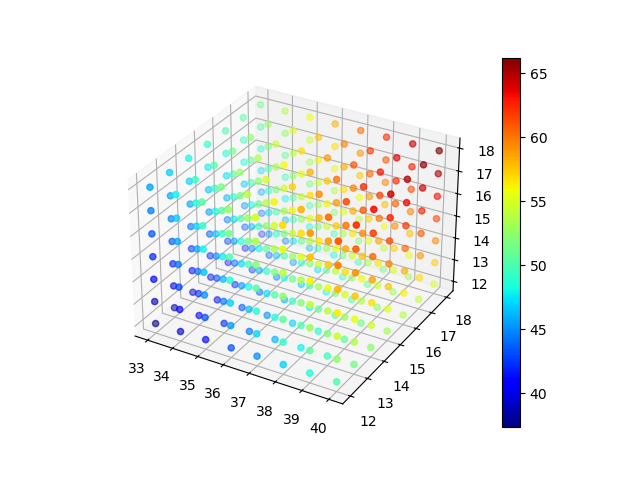

In [7]:
# Represent results as XYZ heat map (success rate info in color)

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
%matplotlib widget

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

L = data[:, 0]
R = data[:, 1]
B = data[:, 2]
S = data[:, 3]

img = ax.scatter(L, R, B, c=S, cmap=plt.jet())
fig.colorbar(img)
plt.show()

In [ ]:
# Tareas
# Aprender a manejar Paraview para hacer unas representaciones chulas
# Aprender cómo obtener puntos sobre la superficie de 50% para ver número mínimo de L, R, B
# Obtener gradientes en cada dirección para ver significancia de añadir 1 carta de cada tipo sobre el % total de éxitos